### Import

In [1]:
import utils as ut

### Parameters

In [2]:
target_column = "AMZN"
input_days= 30
output_days= [1]
test_size=0.2
shuffle=True

### Load dataset

In [3]:
data = ut.read_and_clean_data(file_path = "../dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Converting Date column to datetime...
Load data completed.


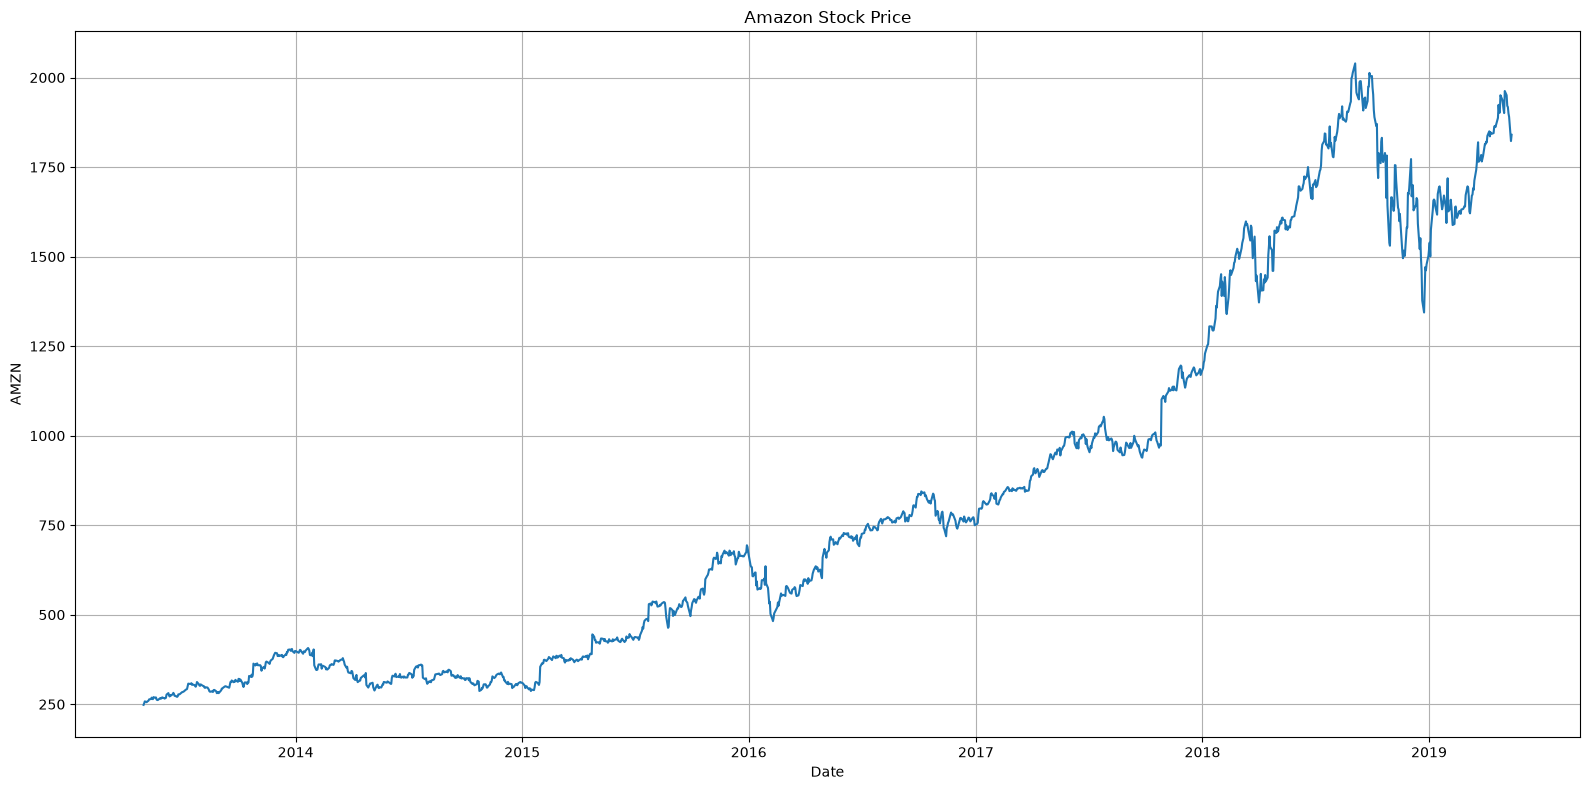

In [4]:
ut.plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [5]:
selected_value = data[target_column].values
window_data = {}
for days in output_days:
    X, y = ut.generate_sliding_windows(
        selected_value,
        input_days,
        days
        )
    window_data[days] = {
        "X" : X,
        "y" : y
    }

Input : 30 days | Output : 1 days | Windows: 1490


### Split Data

In [6]:
train_test_data = ut.split_data(
    window_data,
    output_days,
    test_size,
    shuffle
)

### Data Scaling

In [7]:
scaled_data = ut.scale_all_data(train_test_data)

day- 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)


### Train Regression Models

### Dense Deep Network

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
def generate_model():
    dense_model = Sequential()
    dense_model.add(Dense(8, input_shape = (30,), activation= "relu"))
    dense_model.add(Dense(19, activation= "relu"))
    dense_model.add(Dense(66, activation= "relu"))
    dense_model.add(Dense(101, activation= "relu"))
    dense_model.add(Dense(47, activation= "relu"))
    dense_model.add(Dense(11, activation= "relu"))
    dense_model.add(Dense(1))
    dense_model.summary()

    return dense_model

In [10]:
dense_model = generate_model()

e:\Python Git\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Parameter formol = (input * neorons) + nouron

In [12]:
from tensorflow.keras.optimizers import Adam

dense_model1 = generate_model()
dense_model2 = generate_model()
dense_model3 = generate_model()
dense_model4= generate_model()


dense_model1.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )
dense_model2.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )
dense_model3.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )
dense_model4.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history1 = dense_model1.fit(
    scaled_data[1]["X_train_norm"],
    scaled_data[1]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[1]["X_test_norm"],
    scaled_data[1]["y_test_norm"]
    ),
    verbose= 1,
    batch_size= 64
)

Epoch 1/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0634 - mean_absolute_error: 0.1644 - mean_squared_error: 0.0634 - root_mean_squared_error: 0.2519 - val_loss: 0.0149 - val_mean_absolute_error: 0.1181 - val_mean_squared_error: 0.0149 - val_root_mean_squared_error: 0.1220
Epoch 2/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - mean_absolute_error: 0.0566 - mean_squared_error: 0.0052 - root_mean_squared_error: 0.0722 - val_loss: 0.0013 - val_mean_absolute_error: 0.0228 - val_mean_squared_error: 0.0013 - val_root_mean_squared_error: 0.0358
Epoch 3/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.5383e-04 - mean_absolute_error: 0.0220 - mean_squared_error: 9.5383e-04 - root_mean_squared_error: 0.0309 - val_loss: 7.0457e-04 - val_mean_absolute_error: 0.0174 - val_mean_squared_error: 7.0457e-04 - val_root_mean_squared_error: 0.0265
Epoch 4/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2256e-04 - mean_absolute_error: 0.0184 - mean_squared_error: 7.225

In [14]:
history2 = dense_model2.fit(
    scaled_data[1]["X_train_norm"],
    scaled_data[1]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[1]["X_test_norm"],
    scaled_data[1]["y_test_norm"]
    ),
    verbose=1,
    batch_size = 128
)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0435 - mean_absolute_error: 0.1360 - mean_squared_error: 0.0435 - root_mean_squared_error: 0.2085 - val_loss: 0.0094 - val_mean_absolute_error: 0.0901 - val_mean_squared_error: 0.0094 - val_root_mean_squared_error: 0.0971
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0096 - mean_absolute_error: 0.0869 - mean_squared_error: 0.0096 - root_mean_squared_error: 0.0979 - val_loss: 0.0036 - val_mean_absolute_error: 0.0455 - val_mean_squared_error: 0.0036 - val_root_mean_squared_error: 0.0603
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0039 - mean_absolute_error: 0.0441 - mean_squared_error: 0.0039 - root_mean_squared_error: 0.0624 - val_loss: 0.0014 - val_mean_absolute_error: 0.0273 - val_mean_squared_error: 0.0014 - val_root_mean_squared_error: 0.0372
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0014 - mean_absolute_error: 0.0257 - mean_squared_error: 0.0014 - root_mean_square

In [15]:
history3 = dense_model3.fit(
    scaled_data[1]["X_train_norm"],
    scaled_data[1]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[1]["X_test_norm"],
    scaled_data[1]["y_test_norm"]
    ),
    verbose=1,
    batch_size=512
)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - loss: 0.1579 - mean_absolute_error: 0.2887 - mean_squared_error: 0.1579 - root_mean_squared_error: 0.3974 - val_loss: 0.1294 - val_mean_absolute_error: 0.2554 - val_mean_squared_error: 0.1294 - val_root_mean_squared_error: 0.3598
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1080 - mean_absolute_error: 0.2306 - mean_squared_error: 0.1080 - root_mean_squared_error: 0.3286 - val_loss: 0.0789 - val_mean_absolute_error: 0.1984 - val_mean_squared_error: 0.0789 - val_root_mean_squared_error: 0.2808
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0632 - mean_absolute_error: 0.1773 - mean_squared_error: 0.0632 - root_mean_squared_error: 0.2514 - val_loss: 0.0359 - val_mean_absolute_error: 0.1403 - val_mean_squared_error: 0.0359 - val_root_mean_squared_error: 0.1895
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0274 - mean_absolute_error: 0.1251 - mean_squared_error: 0.0274 - root_mean_squared_error

In [16]:
history4 = dense_model4.fit(
    scaled_data[1]["X_train_norm"],
    scaled_data[1]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[1]["X_test_norm"],
    scaled_data[1]["y_test_norm"]
    ),
    verbose=1,
    batch_size=820
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 545ms/step - loss: 0.1403 - mean_absolute_error: 0.2732 - mean_squared_error: 0.1403 - root_mean_squared_error: 0.3745 - val_loss: 0.1101 - val_mean_absolute_error: 0.2375 - val_mean_squared_error: 0.1101 - val_root_mean_squared_error: 0.3318
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0965 - mean_absolute_error: 0.2192 - mean_squared_error: 0.0965 - root_mean_squared_error: 0.3106 - val_loss: 0.0677 - val_mean_absolute_error: 0.1834 - val_mean_squared_error: 0.0677 - val_root_mean_squared_error: 0.2602
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0566 - mean_absolute_error: 0.1668 - mean_squared_error: 0.0566 - root_mean_squared_error: 0.2379 - val_loss: 0.0327 - val_mean_absolute_error: 0.1305 - val_mean_squared_error: 0.0327 - val_root_mean_squared_error: 0.1808
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0265 - mean_absolute_error: 0.1175 - mean_squared_error: 0.0265 - root_mean_squared_er

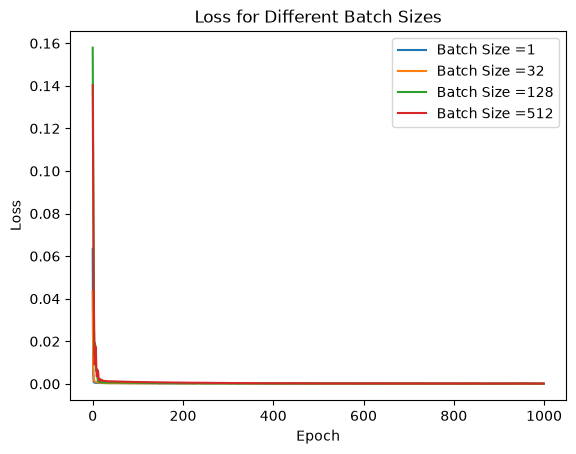

In [17]:
# Training
import matplotlib.pyplot as plt

plt.plot(history1.history["loss"], label= "Batch Size =1")
plt.plot(history2.history["loss"], label="Batch Size =32")
plt.plot(history3.history["loss"], label="Batch Size =128")
plt.plot(history4.history["loss"], label="Batch Size =512")

plt.title("Loss for Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

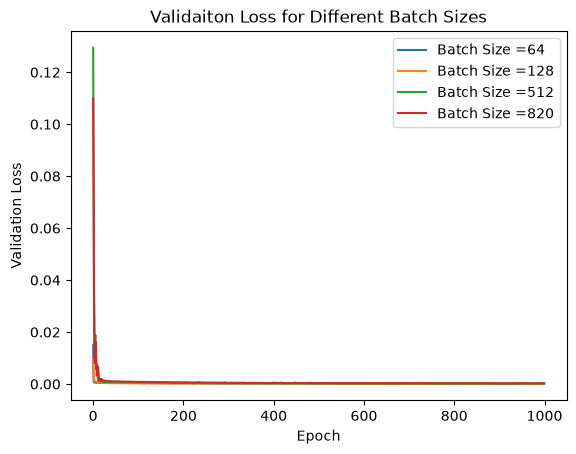

In [19]:
# Validation
import matplotlib.pyplot as plt

plt.plot(history1.history["val_loss"], label= "Batch Size =64")
plt.plot(history2.history["val_loss"], label="Batch Size =128")
plt.plot(history3.history["val_loss"], label="Batch Size =512")
plt.plot(history4.history["val_loss"], label="Batch Size =820")

plt.title("Validaiton Loss for Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()